# Charger le datraframe #

In [442]:
import pandas as pd
# import unicodedata
import matplotlib.pyplot as plt
import seaborn as sns


In [443]:

df = pd.read_csv(
    "ncr_ride_bookings.csv",
    sep=",",
    quotechar='"',
    encoding="utf-8"
)


In [444]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [445]:
print(df["Payment Method"].value_counts(dropna=False))

Payment Method
NaN            48000
UPI            45909
Cash           25367
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64


In [446]:
# Créer une vraie copie originale
df_original = df.copy()

# Vérifier les valeurs manquantes
print("Nombre de NaN :")
print(df_original["Booking Status"].isna().sum())

Nombre de NaN :
0


In [447]:
# 2) Vérifier avant tout nettoyage
print(df["Booking Status"].value_counts(dropna=False))


Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [448]:
print("Avant tout nettoyage:")
print(df["Booking Status"].isna().sum())

Avant tout nettoyage:
0


In [449]:
print(df["Booking Status"].value_counts(dropna=False))

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


In [450]:
# Créer une copie avant le nettoyage
df_before = df.copy()

In [451]:
# Vérifier les valeurs avant nettoyage
df_before["Booking Status"].value_counts(dropna=False)

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [452]:
print("Avant tout nettoyage:")
print(df["Booking Status"].isna().sum())

Avant tout nettoyage:
0


# Supprime les espaces au début et à la fin des noms de colonnes #

In [453]:
df.columns = df.columns.str.strip()

# Supprimer les doublons #

In [454]:
df = df.drop_duplicates()

# Supprimer les espaces en début de chaque valeur #

In [455]:
# Sélection des colonnes de type chaîne
string_cols = df.select_dtypes(include="object").columns

# Suppression des espaces en début et fin de chaque valeur
df[string_cols] = df[string_cols].apply(lambda col: col.str.strip())
# remplacer les espaces multiples par un seul
df[string_cols] = df[string_cols].apply(
    lambda col: col.str.replace(r"\s+", " ", regex=True).str.strip()
)
# vérifier que les espaces ont bien été supprimés
print(df.columns.tolist())

for col in string_cols:
    print(df[col].head())

['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']
0    2024-03-23
1    2024-11-29
2    2024-08-23
3    2024-10-21
4    2024-09-16
Name: Date, dtype: object
0    12:29:38
1    18:01:39
2    08:56:10
3    17:17:25
4    22:08:00
Name: Time, dtype: object
0    "CNR5884300"
1    "CNR1326809"
2    "CNR8494506"
3    "CNR8906825"
4    "CNR1950162"
Name: Booking ID, dtype: object
0    No Driver Found
1         Incomplete
2          Completed
3          Completed
4          Completed
Name: Booking Status, dtype: object
0    "CID1982111"
1    "CID4604802"
2    "CID9202816"
3    "CID2610914"
4    "CID9933542"
Name: Customer ID, dtype: object
0        

# Uniformiser les booking id #

In [456]:
id_cols = ["Booking ID", "Customer ID"]

for col in id_cols:
    df[col] = df[col].str.replace('"', '', regex=False).str.strip()

# Uniformiser les dates #

In [457]:
import re
from datetime import datetime

def uniformiser_date(date):

    if not isinstance(date, str):
        return None

    date = date.strip()

    # Uniformiser les séparateurs
    date = re.sub(r"\s*-\s*", "-", date)
    date = re.sub(r"\s+", "-", date)
    date = date.replace("/", "-")

    formats = [
        "%Y-%m-%d",   # 1995-02-10
        "%m-%d-%Y",   # 09-21-1972
        "%d-%m-%Y",   # 23-07-2008
        "%d-%b-%y",   # 22-Feb-04
        "%d-%B-%Y",   # 22-February-2004
        "%d-%b-%Y",   # 22-Feb-2004
    ]

    for fmt in formats:
        try:
            d = datetime.strptime(date, fmt)
            return d.strftime("%Y/%m/%d")
        except ValueError:
            pass

    return None

df["Date"] = df["Date"].apply(uniformiser_date)

# Distribution de la valeur des réservations #

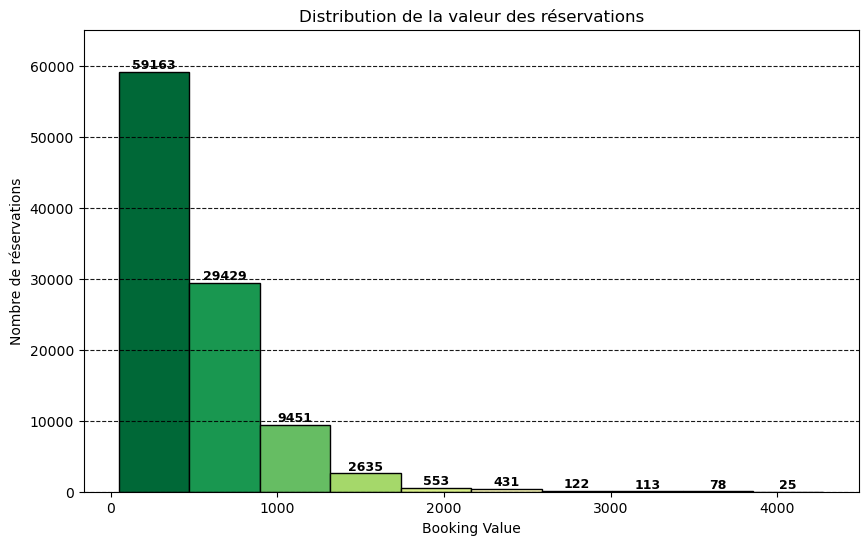

In [458]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

plt.figure(figsize=(10,6))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Booking Value"].dropna(),
    bins=10,
    edgecolor="black"
)

# Normalisation des valeurs des classes
norm = mcolors.Normalize(vmin=bins.min(), vmax=bins.max())
cmap = plt.colormaps["RdYlGn_r"]  # Vert → Jaune → Rouge

# Attribution des couleurs
for i, patch in enumerate(patches):
    patch.set_facecolor(cmap(norm(bins[i])))

# Affichage des effectifs sur chaque barre
for count, patch in zip(n, patches):
    if count > 0:  # N'affiche pas les classes vides
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.title("Distribution de la valeur des réservations")
plt.xlabel("Booking Value")
plt.ylabel("Nombre de réservations")
plt.grid(axis="y", linestyle="--", alpha=0.9, color="black")

# Laisse un peu d'espace au-dessus des barres pour les étiquettes
plt.ylim(0, max(n) * 1.1)

plt.show()

In [459]:
df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024/03/23,12:29:38,CNR5884300,No Driver Found,CID1982111,eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024/11/29,18:01:39,CNR1326809,Incomplete,CID4604802,Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024/08/23,08:56:10,CNR8494506,Completed,CID9202816,Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024/10/21,17:17:25,CNR8906825,Completed,CID2610914,Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024/09/16,22:08:00,CNR1950162,Completed,CID9933542,Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


# Distribution de la distance en fonction du nombre de courses #

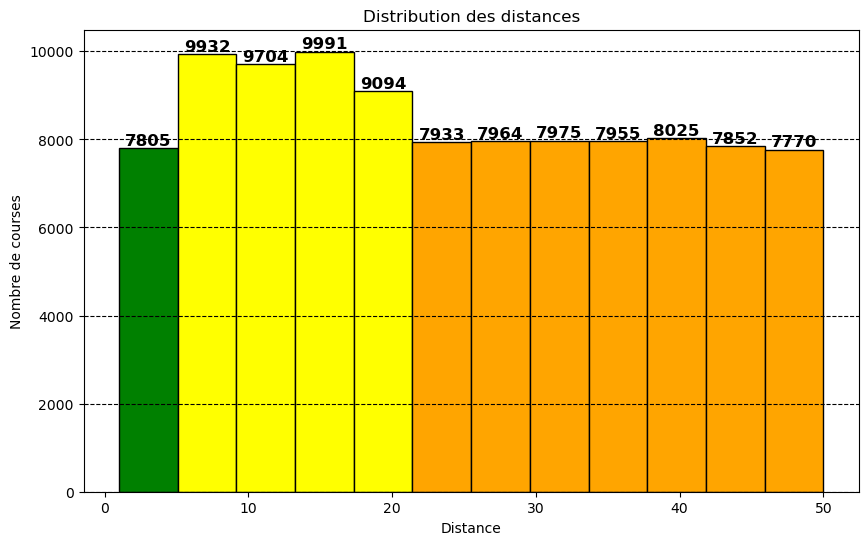

In [460]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Ride Distance"].dropna(),
    bins=12,
    edgecolor="black"

)

# Coloration selon la distance
for i, patch in enumerate(patches):
    if bins[i] < 5:
        patch.set_facecolor("green")
    elif bins[i] < 20:
        patch.set_facecolor("yellow")
    elif bins[i] < 50:
        patch.set_facecolor("orange")
    else:
        patch.set_facecolor("red")

# Affichage des effectifs sur chaque barre
for count, patch in zip(n, patches):
    if count > 0:  # n'affiche pas les classes vides
        plt.text(
            patch.get_x() + patch.get_width()/2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight= "bold"
            
        )

        

plt.title("Distribution des distances")
plt.xlabel("Distance")
plt.ylabel("Nombre de courses")
plt.grid(axis="y", linestyle="--", alpha=1.0, color="black")

plt.show()

# Répartitions des réservations #

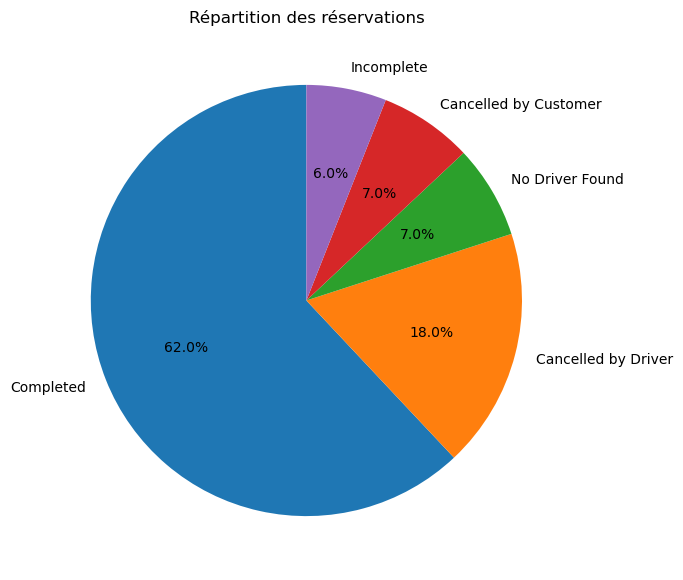

In [461]:
status = df["Booking Status"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(status.values,
        labels=status.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Répartition des réservations")

plt.show()

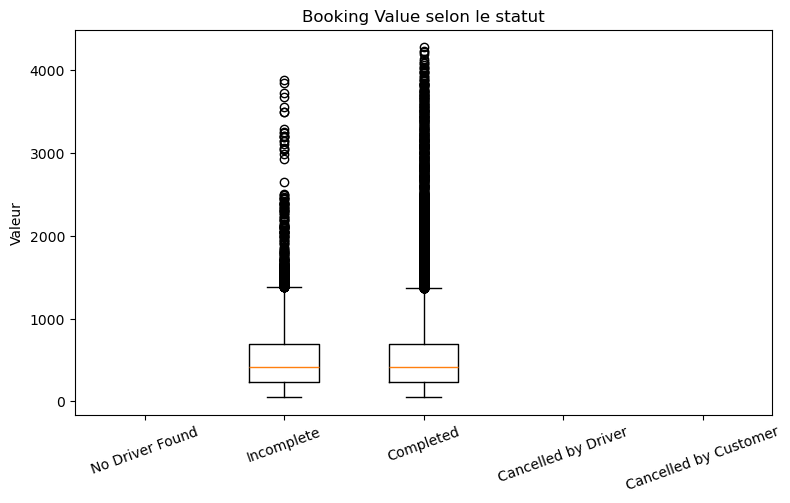

In [462]:
data = []
labels= []
for statut in df["Booking Status"].unique():
    data.append(
        df[df["Booking Status"] == statut]["Booking Value"].dropna()
    )

plt.figure(figsize=(9,5))

plt.boxplot(data,
            tick_labels=df["Booking Status"].unique())

plt.xticks(rotation=20)

plt.title("Booking Value selon le statut")

plt.ylabel("Valeur")

plt.show()

# Répartition des status des réservations #

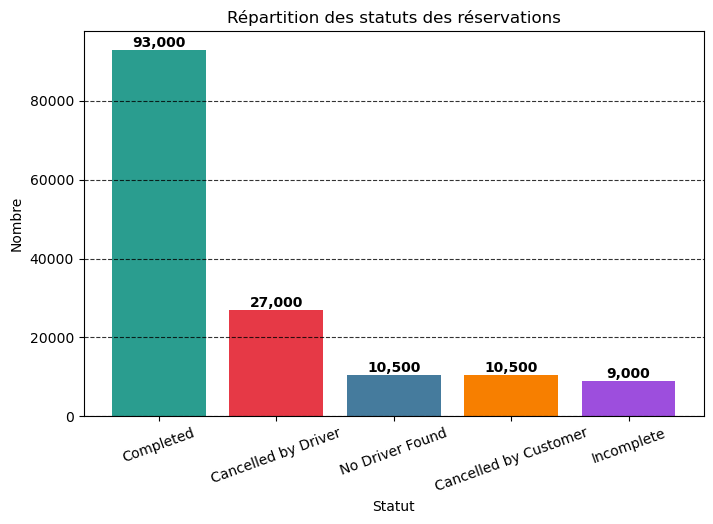

In [463]:
status = df["Booking Status"].value_counts()

couleurs = {
    "Completed": "#2A9D8F",
    "Cancelled by Driver": "#E63946",
    "Cancelled by Customer": "#F77F00",
    "No Driver Found": "#457B9D",
    "Incomplete": "#9D4EDD"
}

bar_colors = [couleurs[s] for s in status.index]

plt.figure(figsize=(8,5))

bars = plt.bar(status.index,
               status.values,
               color=bar_colors)

plt.title("Répartition des statuts des réservations")
plt.xlabel("Statut")
plt.ylabel("Nombre")

plt.xticks(rotation=20)

# Affichage des valeurs sur les barres
for bar in bars:
    hauteur = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        hauteur,
        f"{int(hauteur):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.grid(axis="y", linestyle="--", alpha=0.8, color="black")

plt.show()

# Répartition des notes des chauffeurs #

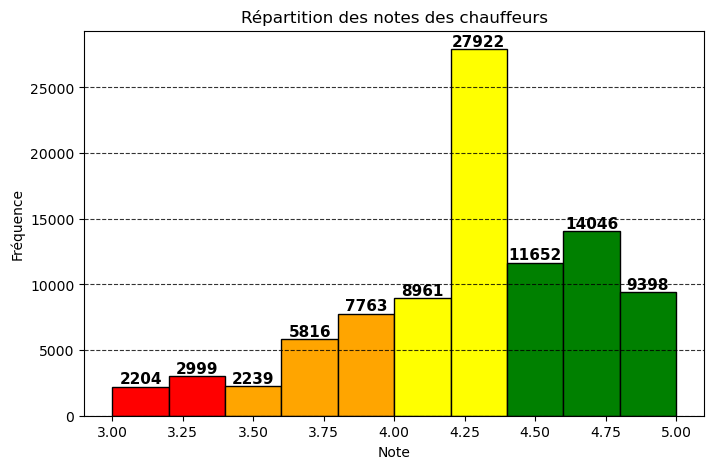

In [464]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Création de l'histogramme
n, bins, patches = plt.hist(
    df["Driver Ratings"].dropna(),
    bins=10,
    edgecolor="black"
)

# Couleur des barres selon la note
for i in range(len(patches)):
    centre = (bins[i] + bins[i+1]) / 2

    if centre < 3.5:
        patches[i].set_facecolor("red")      # Mauvaise note
    elif centre < 4.0:
        patches[i].set_facecolor("orange")   # Note moyenne
    elif centre < 4.5:
        patches[i].set_facecolor("yellow")   # Bonne note
    else:
        patches[i].set_facecolor("green")    # Excellente note

plt.title("Répartition des notes des chauffeurs")
plt.xlabel("Note")
plt.ylabel("Fréquence")

plt.grid(axis="y",
         linestyle="--",
         alpha=0.8,
         color="black")
for count, patch in zip(n, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

plt.show()

# Répartition des notes des clients #

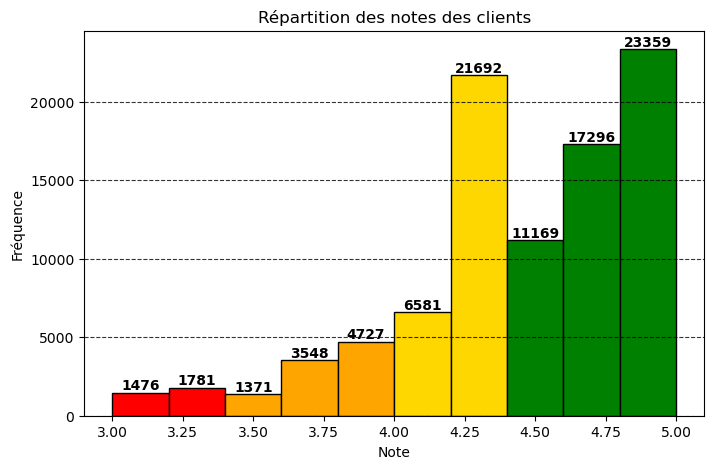

In [465]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

n, bins, patches = plt.hist(
    df["Customer Rating"].dropna(),
    bins=10,
    edgecolor="black"
)

# Coloration des barres selon la note
for i in range(len(patches)):
    centre = (bins[i] + bins[i+1]) / 2

    if centre < 3.5:
        patches[i].set_facecolor("red")
    elif centre < 4.0:
        patches[i].set_facecolor("orange")
    elif centre < 4.5:
        patches[i].set_facecolor("gold")
    else:
        patches[i].set_facecolor("green")

plt.title("Répartition des notes des clients")
plt.xlabel("Note")
plt.ylabel("Fréquence")
plt.grid(axis="y", linestyle="--", alpha=0.8, color ="black")

for count, patch in zip(n, patches):
    if count > 0:
        plt.text(
            patch.get_x() + patch.get_width() / 2,
            count,
            f"{int(count)}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )
plt.show()

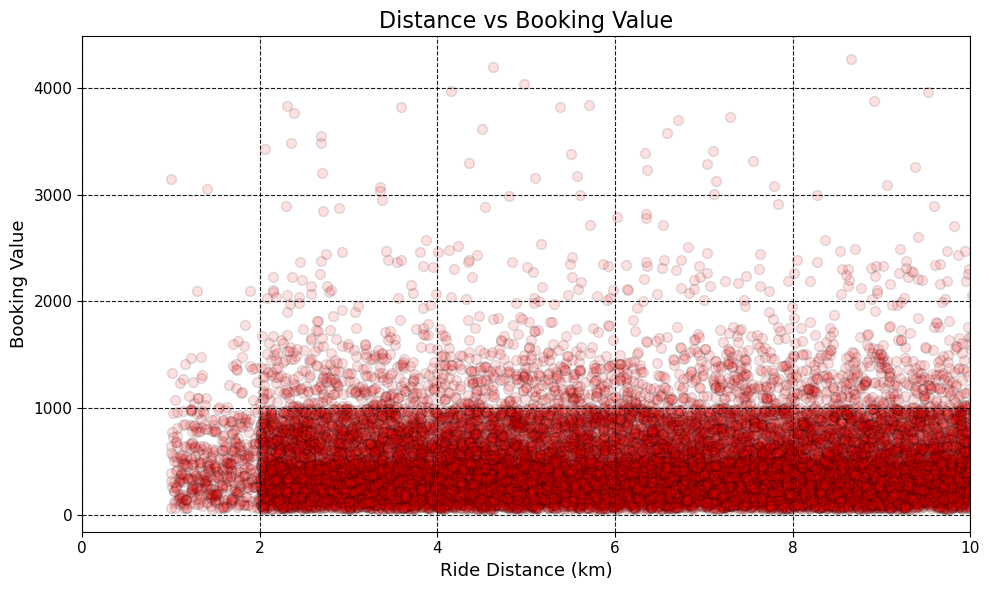

In [466]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Ride Distance"],
    df["Booking Value"],
    alpha=0.12,
    color="red",
    s=50,               # Taille des points
    edgecolors="black", # Contour des points
    linewidth=1
)

plt.title("Distance vs Booking Value", fontsize=16)
plt.xlabel("Ride Distance (km)", fontsize=13)
plt.ylabel("Booking Value", fontsize=13)

# Taille des graduations
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Afficher uniquement les distances entre 0 et 10
plt.xlim(0, 10)

plt.grid(True, linestyle="--", alpha=0.9, color= "black")

plt.tight_layout()
plt.show()

# Temps d'attente moyen pour l'arrivée d'un véhicule d'un conducteur #

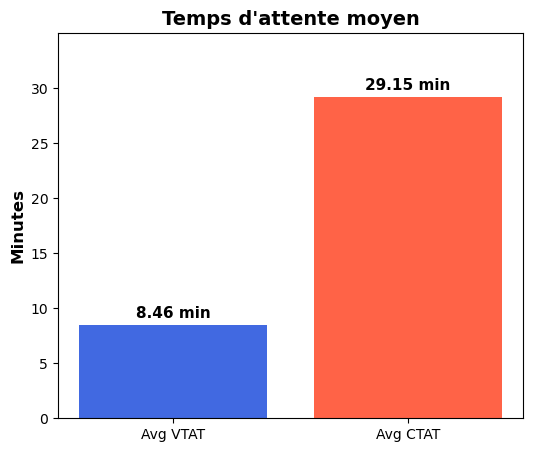

In [467]:
import matplotlib.pyplot as plt

moyennes = [
    df["Avg VTAT"].mean(),
    df["Avg CTAT"].mean()
]

labels = ["Avg VTAT", "Avg CTAT"]

plt.figure(figsize=(6,5))

bars = plt.bar(
    labels,
    moyennes,
    color=["royalblue", "tomato"]
)

# Affichage des valeurs au-dessus des barres
plt.bar_label(
    bars,
    fmt="%.2f min",      # 2 décimales + unité
    fontsize=11,
    fontweight="bold",
    padding=3
)

plt.ylabel("Minutes", fontsize=12, fontweight="bold")
plt.title("Temps d'attente moyen", fontsize=14, fontweight="bold")
plt.ylim(0, max(moyennes) * 1.2)

plt.show()

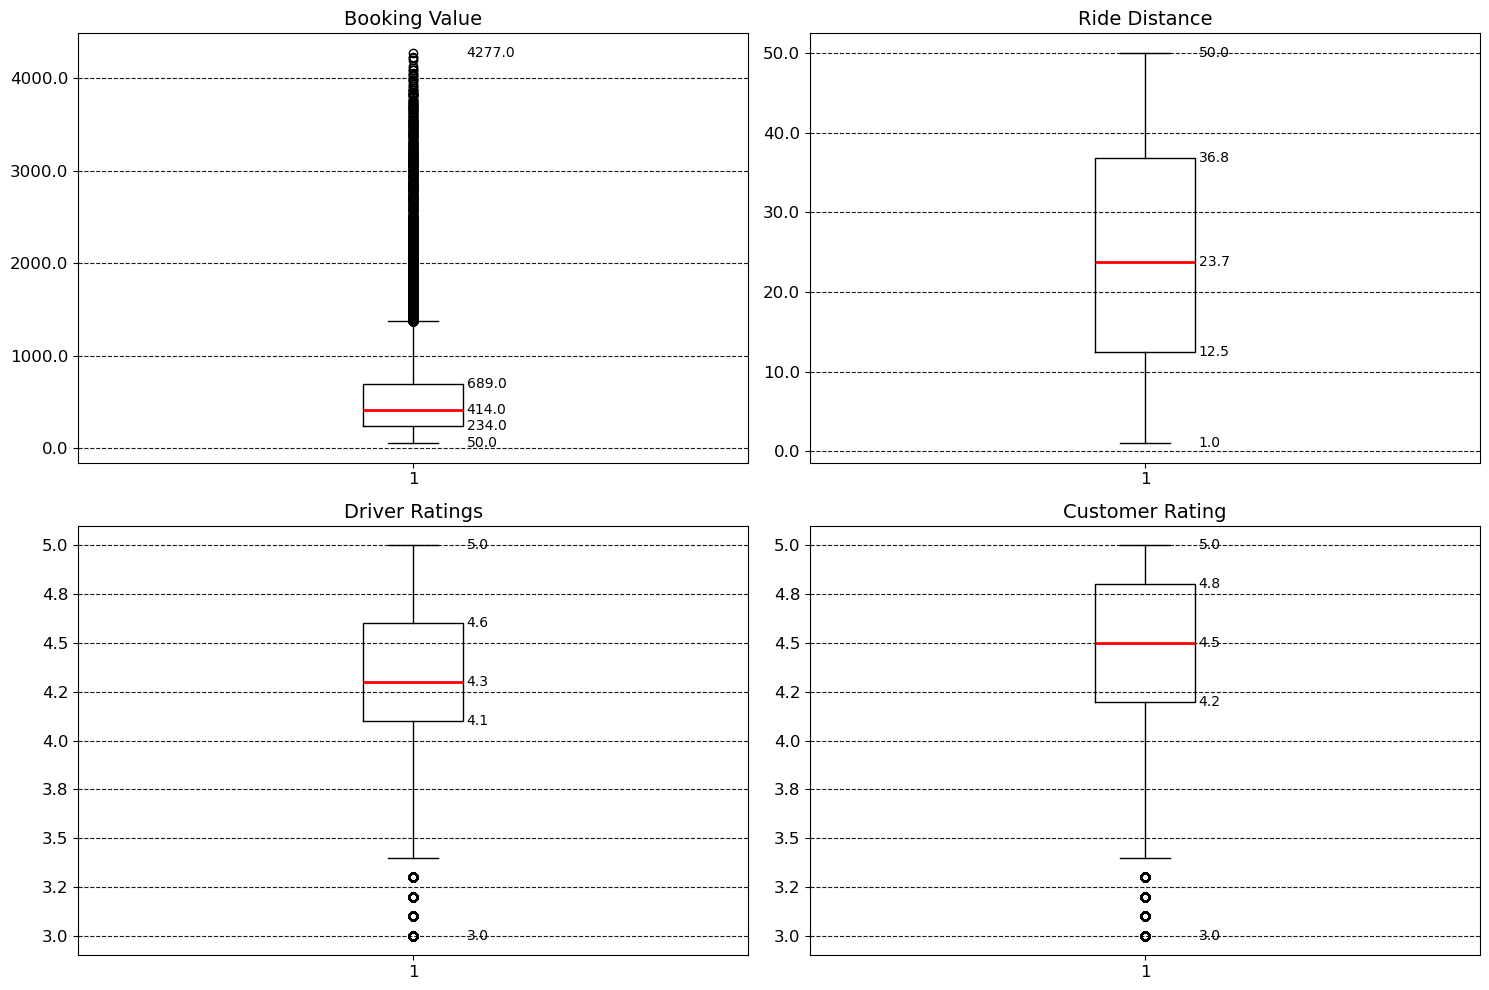

In [468]:
import numpy as np
from matplotlib.ticker import FormatStrFormatter

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

colonnes = [
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]

for axes, colonne in zip(ax.flat, colonnes):
    valeurs = df[colonne].dropna()

    axes.boxplot(
        valeurs,
        medianprops={"color": "red", "linewidth": 2}
    )

    axes.set_title(colonne, fontsize=14)
    axes.tick_params(labelsize=12)
    axes.grid(axis="y", linestyle="--", alpha=0.9, color="black")
    axes.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

    # Calcul des statistiques
    mini = valeurs.min()
    q1 = valeurs.quantile(0.25)
    med = valeurs.median()
    q3 = valeurs.quantile(0.75)
    maxi = valeurs.max()

    # Affichage des valeurs
    for y in [mini, q1, med, q3, maxi]:
        axes.text(
            1.08, y,
            f"{y:.1f}",
            va="center",
            fontsize=10
        )

plt.tight_layout()
plt.show()

pourventage de donnes manquantes

In [469]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
}).sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Incomplete Rides Reason,141000,94.0
Incomplete Rides,141000,94.0
Cancelled Rides by Customer,139500,93.0
Reason for cancelling by Customer,139500,93.0
Driver Cancellation Reason,123000,82.0
Cancelled Rides by Driver,123000,82.0
Customer Rating,57000,38.0
Driver Ratings,57000,38.0
Ride Distance,48000,32.0
Booking Value,48000,32.0


In [470]:
df.groupby("Booking Status")["Booking Value"].apply(lambda x: x.isna().sum())

Booking Status
Cancelled by Customer    10500
Cancelled by Driver      27000
Completed                    0
Incomplete                   0
No Driver Found          10500
Name: Booking Value, dtype: int64

In [471]:
df.groupby("Booking Status")["Ride Distance"].apply(lambda x: x.isna().sum())

Booking Status
Cancelled by Customer    10500
Cancelled by Driver      27000
Completed                    0
Incomplete                   0
No Driver Found          10500
Name: Ride Distance, dtype: int64

In [472]:
df.groupby("Booking Status")["Customer Rating"].apply(lambda x: x.isna().sum())

Booking Status
Cancelled by Customer    10500
Cancelled by Driver      27000
Completed                    0
Incomplete                9000
No Driver Found          10500
Name: Customer Rating, dtype: int64

# nettoyage des columns de texte #

In [473]:
text_cols = [
    "Reason for cancelling by Customer",
    "Driver Cancellation Reason",
    "Incomplete Rides Reason"
]

df[text_cols].head(10)

,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason
0,NaN,NaN,NaN
1,NaN,NaN,Vehicle Breakdown
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,Other Issue


In [474]:
df[text_cols].isnull().sum()

Reason for cancelling by Customer    139500
Driver Cancellation Reason           123000
Incomplete Rides Reason              141000
dtype: int64

In [475]:
df[text_cols][df[text_cols].isnull().any(axis=1)].head(10)

,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason
0,NaN,NaN,NaN
1,NaN,NaN,Vehicle Breakdown
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,NaN,NaN,NaN
8,NaN,NaN,NaN
9,NaN,NaN,Other Issue


In [476]:
for col in text_cols:
    print(f"\n{col}")
    print(df[col].value_counts(dropna=False))


Reason for cancelling by Customer
Reason for cancelling by Customer
NaN                                             139500
Wrong Address                                     2362
Change of plans                                   2353
Driver is not moving towards pickup location      2335
Driver asked to cancel                            2295
AC is not working                                 1155
Name: count, dtype: int64

Driver Cancellation Reason
Driver Cancellation Reason
NaN                                    123000
Customer related issue                   6837
The customer was coughing/sick           6751
Personal & Car related issues            6726
More than permitted people in there      6686
Name: count, dtype: int64

Incomplete Rides Reason
Incomplete Rides Reason
NaN                  141000
Customer Demand        3040
Vehicle Breakdown      3012
Other Issue            2948
Name: count, dtype: int64


In [477]:
df[text_cols] = df[text_cols].fillna("Not Applicable")

In [478]:
df[text_cols].head(10)

,Reason for cancelling by Customer,Driver Cancellation Reason,Incomplete Rides Reason
0,Not Applicable,Not Applicable,Not Applicable
1,Not Applicable,Not Applicable,Vehicle Breakdown
2,Not Applicable,Not Applicable,Not Applicable
3,Not Applicable,Not Applicable,Not Applicable
4,Not Applicable,Not Applicable,Not Applicable
5,Not Applicable,Not Applicable,Not Applicable
6,Not Applicable,Not Applicable,Not Applicable
7,Not Applicable,Not Applicable,Not Applicable
8,Not Applicable,Not Applicable,Not Applicable
9,Not Applicable,Not Applicable,Other Issue


In [479]:
df[text_cols].isnull().sum()

Reason for cancelling by Customer    0
Driver Cancellation Reason           0
Incomplete Rides Reason              0
dtype: int64

# nettoyage des columns numeric

In [480]:
print(df["Cancelled Rides by Customer"].value_counts(dropna=False))
print(df["Cancelled Rides by Driver"].value_counts(dropna=False))
print(df["Incomplete Rides"].value_counts(dropna=False))

Cancelled Rides by Customer
NaN    139500
1.0     10500
Name: count, dtype: int64
Cancelled Rides by Driver
NaN    123000
1.0     27000
Name: count, dtype: int64
Incomplete Rides
NaN    141000
1.0      9000
Name: count, dtype: int64


In [481]:
cols = [
    "Cancelled Rides by Customer",
    "Cancelled Rides by Driver",
    "Incomplete Rides"
]

before = df[cols].copy()

df["Cancelled Rides by Customer"] = df["Cancelled Rides by Customer"].fillna(0)
df["Cancelled Rides by Driver"] = df["Cancelled Rides by Driver"].fillna(0)
df["Incomplete Rides"] = df["Incomplete Rides"].fillna(0)

after = df[cols]

print("Before:")
print(before.head())

print("\nAfter:")
print(after.head())

Before:
   Cancelled Rides by Customer  Cancelled Rides by Driver  Incomplete Rides
0                          NaN                        NaN               NaN
1                          NaN                        NaN               1.0
2                          NaN                        NaN               NaN
3                          NaN                        NaN               NaN
4                          NaN                        NaN               NaN

After:
   Cancelled Rides by Customer  Cancelled Rides by Driver  Incomplete Rides
0                          0.0                        0.0               0.0
1                          0.0                        0.0               1.0
2                          0.0                        0.0               0.0
3                          0.0                        0.0               0.0
4                          0.0                        0.0               0.0


In [482]:
customer_cancel_rate = df["Cancelled Rides by Customer"].mean() * 100
print(customer_cancel_rate)

7.000000000000001


# Nettoyer les statuts de réservation #

In [483]:
df["Booking Status"].value_counts(dropna=False)


Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

J’ai effectué un nettoyage de la colonne Booking Status pour rendre les données cohérentes avant l’analyse.

Premièrement, j’ai affiché les premières lignes de la colonne avant le nettoyage afin de voir la structure initiale des données.

Ensuite, j’ai appliqué plusieurs transformations :

J’ai utilisé str.strip() pour supprimer les espaces inutiles au début et à la fin des valeurs.
J’ai utilisé str.title() pour uniformiser l’écriture des catégories en mettant les premières lettres en majuscule.
J’ai créé un dictionnaire status_mapping pour corriger les différentes écritures qui représentent la même catégorie et garder des noms de statuts uniformes.

Par exemple :

completed
COMPLETED
Completed

deviennent tous :

Completed

Enfin, j’ai affiché les données après le nettoyage pour vérifier que les modifications ont bien été appliquées.

L’objectif de cette étape est d’éviter d’avoir plusieurs catégories pour le même statut, ce qui pourrait fausser les analyses et les statistiques.


J’ai nettoyé la colonne Booking Status en supprimant les espaces inutiles, en uniformisant les majuscules et minuscules, puis en regroupant les valeurs qui représentent la même catégorie. Cette étape permet d’avoir des données propres et fiables pour l’analyse.

In [484]:
df["Booking Status"].isna().sum()

np.int64(0)

In [485]:
# Sauvegarder une copie de la colonne avant le nettoyage
before = df["Booking Status"].copy()


# Nettoyer la colonne Booking Status
# Supprimer les espaces inutiles

# Mettre les valeurs dans un format uniforme
df["Booking Status"] = (
    df["Booking Status"]
    .str.strip()
    .str.title()
)


# Corriger les catégories pour avoir des noms cohérents
status_mapping = {
    "Completed": "Completed",
    "Cancelled By Customer": "Cancelled by Customer",
    "Cancelled By Driver": "Cancelled by Driver",
    "Incomplete": "Incomplete",
    "No Driver Found": "No Driver Found"
}

df["Booking Status"] = df["Booking Status"].replace(status_mapping)


# Comparer les valeurs avant et après le nettoyage
comparison = pd.DataFrame({
    "Avant nettoyage": before.head(10),
    "Après nettoyage": df["Booking Status"].head(10)
})

comparison

,Avant nettoyage,Après nettoyage
0,No Driver Found,No Driver Found
1,Incomplete,Incomplete
2,Completed,Completed
3,Completed,Completed
4,Completed,Completed
5,Completed,Completed
6,Completed,Completed
7,Completed,Completed
8,No Driver Found,No Driver Found
9,Incomplete,Incomplete


# Remplacer les valeurs manqantes en Avg VTAT

In [486]:
#j'ai remplacé les valeurs manquantes de la colonne Avg VTAT par la médiane et non par la moyenne.
# La médiane est plus robuste face aux valeurs extrêmes (outliers).
#  Si certaines courses ont un temps d’attente exceptionnellement élevé,
#  la moyenne sera influencée, alors que la médiane représente mieux la valeur centrale des données.

# ==========================
# 1) Sauvegarder une copie avant le nettoyage
# ==========================

# Créer une copie de la colonne avant de remplacer les valeurs manquantes
before = df["Avg VTAT"].copy()


# Afficher les premières valeurs avant le remplacement
print("Avant fillna :")
print(before.head(20))

# Afficher le nombre de valeurs manquantes avant le nettoyage
print("\nNombre de NaN avant :", before.isna().sum())


# ==========================
# 2) Remplacer les valeurs manquantes par la médiane
# ==========================

# Calculer la médiane de la colonne Avg VTAT
median_vtat = df["Avg VTAT"].median()

# Remplacer les valeurs NaN par la médiane
df["Avg VTAT"] = df["Avg VTAT"].fillna(median_vtat)


# ==========================
# 3) Afficher le résultat après le nettoyage
# ==========================

print("\nAprès fillna :")
print(df["Avg VTAT"].head(20))

# Vérifier qu'il ne reste plus de valeurs manquantes
print("\nNombre de NaN après :", df["Avg VTAT"].isna().sum())


# ==========================
# 4) Comparaison avant / après
# ==========================

comparison = pd.DataFrame({
    "Avant fillna": before.head(20),
    "Après fillna": df["Avg VTAT"].head(20)
})

comparison

Avant fillna :
0      NaN
1      4.9
2     13.4
3     13.1
4      5.3
5      5.1
6      7.1
7     12.1
8      NaN
9      6.1
10     7.7
11     NaN
12     4.6
13    12.2
14    14.0
15     8.5
16     5.6
17     6.0
18    12.4
19    10.3
Name: Avg VTAT, dtype: float64

Nombre de NaN avant : 10500

Après fillna :
0      8.3
1      4.9
2     13.4
3     13.1
4      5.3
5      5.1
6      7.1
7     12.1
8      8.3
9      6.1
10     7.7
11     8.3
12     4.6
13    12.2
14    14.0
15     8.5
16     5.6
17     6.0
18    12.4
19    10.3
Name: Avg VTAT, dtype: float64

Nombre de NaN après : 0


,Avant fillna,Après fillna
0,NaN,8.3
1,4.9,4.9
2,13.4,13.4
3,13.1,13.1
4,5.3,5.3
5,5.1,5.1
6,7.1,7.1
7,12.1,12.1
8,NaN,8.3
9,6.1,6.1


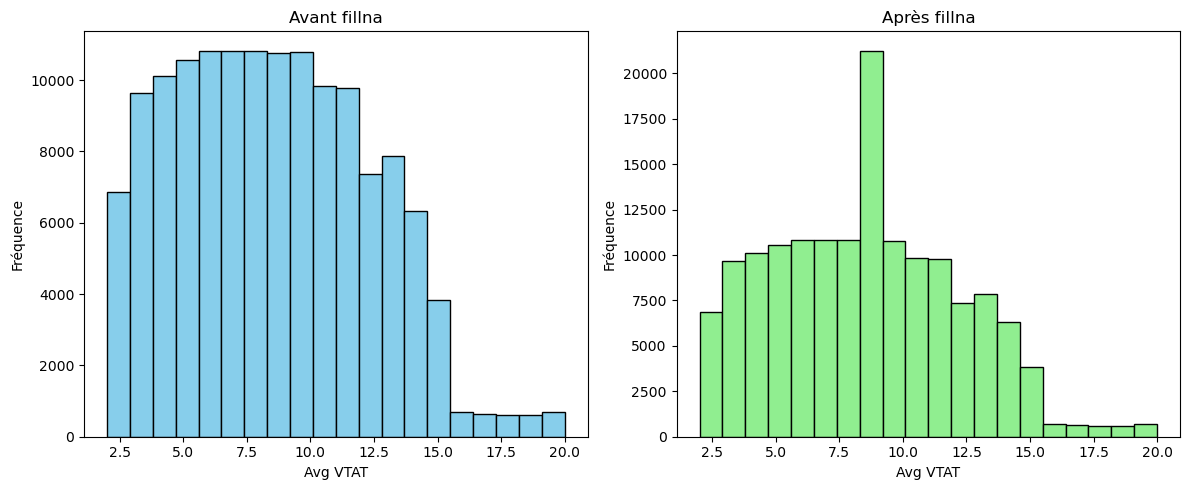

In [487]:
import matplotlib.pyplot as plt

#ce graphique compare la distribution de la colonne Avg VTAT avant et après le traitement des valeurs manquantes.

# À gauche (Avant fillna) : l’histogramme montre uniquement les valeurs disponibles, car les valeurs NaN ne sont pas prises en compte dans le graphique.
# À droite (Après fillna) : après avoir remplacé les valeurs manquantes par la médiane, toutes les observations sont présentes dans la distribution.
# Le choix de la médiane permet de conserver une distribution proche de l’originale, car elle est moins influencée par les valeurs extrêmes que la moyenne.
# L’objectif est d’obtenir un jeu de données complet sans introduire de biais importants dans la distribution de la variable

plt.figure(figsize=(12,5))

# Avant fillna
plt.subplot(1,2,1)
plt.hist(before.dropna(), bins=20, color="skyblue", edgecolor="black")
plt.title("Avant fillna")
plt.xlabel("Avg VTAT")
plt.ylabel("Fréquence")

# Après fillna
plt.subplot(1,2,2)
plt.hist(df["Avg VTAT"], bins=20, color="lightgreen", edgecolor="black")
plt.title("Après fillna")
plt.xlabel("Avg VTAT")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()

# Remplacer les valeurs manqantes en Avg CTAT

In [488]:
df.groupby("Booking Status")["Avg CTAT"].apply(lambda x: x.isna().sum())

Booking Status
Cancelled by Customer    10500
Cancelled by Driver      27000
Completed                    0
Incomplete                   0
No Driver Found          10500
Name: Avg CTAT, dtype: int64

In [489]:
# Afficher un échantillon des lignes avec Avg CTAT manquant

#J’ai analysé les valeurs manquantes de la colonne Avg CTAT en fonction du statut de réservation.
#  J’ai constaté que les valeurs manquantes apparaissent uniquement pour les réservations annulées ou lorsqu’aucun chauffeur n’a été trouvé. 
# Ces valeurs sont donc cohérentes avec le processus métier et ne correspondent pas à une erreur de données.
#  J’ai choisi de conserver les NaN afin de ne pas introduire des informations artificielles dans le dataset
sample = df[
    (df["Avg CTAT"].isna()) &
    (df["Booking Status"].isin([
        "Cancelled by Customer",
        "Cancelled by Driver",
        "No Driver Found"
    ]))
][["Booking ID", "Booking Status", "Avg CTAT"]]

sample.head(15)

,Booking ID,Booking Status,Avg CTAT
0,CNR5884300,No Driver Found,NaN
8,CNR4510807,No Driver Found,NaN
11,CNR9551927,No Driver Found,NaN
12,CNR4386945,Cancelled by Driver,NaN
17,CNR6739317,Cancelled by Driver,NaN
18,CNR6126048,Cancelled by Customer,NaN
19,CNR9465840,Cancelled by Driver,NaN
26,CNR3614535,Cancelled by Driver,NaN
27,CNR4499383,No Driver Found,NaN
30,CNR2178654,Cancelled by Driver,NaN


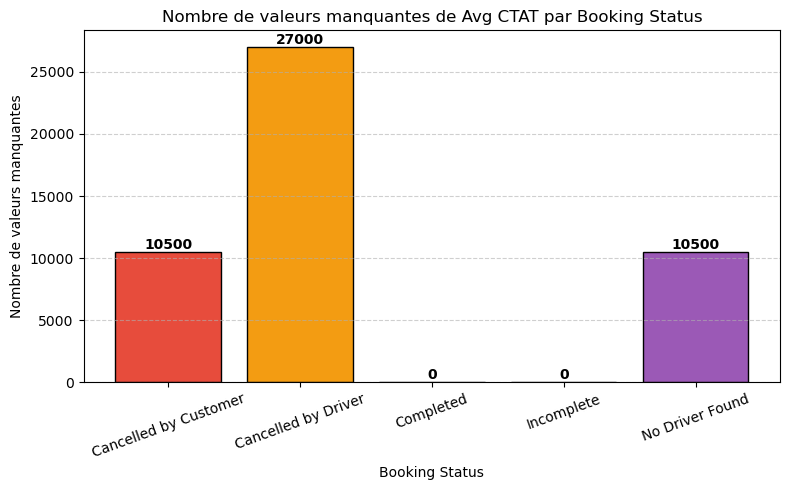

In [490]:
import matplotlib.pyplot as plt
# Ce graphique montre le nombre de valeurs manquantes de la colonne Avg CTAT selon le statut de réservation.
#  On observe que les valeurs manquantes apparaissent uniquement pour les réservations annulées ou lorsqu'aucun chauffeur n'a été trouvé.
#  En revanche, les réservations Completed et Incomplete possèdent toutes une valeur Avg CTAT.
#  Cela indique que les valeurs manquantes sont cohérentes avec le processus métier et ne représentent pas une erreur dans les données.
# Calculer le nombre de valeurs manquantes par statut

missing_ctat = df.groupby("Booking Status")["Avg CTAT"].apply(lambda x: x.isna().sum())

# Créer le graphique
plt.figure(figsize=(8,5))
bars = plt.bar(
    missing_ctat.index,
    missing_ctat.values,
    color=["#e74c3c", "#f39c12", "#2ecc71", "#3498db", "#9b59b6"],
    edgecolor="black"
)

# Ajouter les valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Nombre de valeurs manquantes de Avg CTAT par Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Nombre de valeurs manquantes")
plt.xticks(rotation=20)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [491]:
missing = df.isnull().sum()

missing[missing > 0]

Avg CTAT           48000
Booking Value      48000
Ride Distance      48000
Driver Ratings     57000
Customer Rating    57000
Payment Method     48000
dtype: int64

In [492]:
# J’ai analysé les valeurs manquantes colonne par colonne.
#  Ensuite, j’ai décidé du traitement en fonction de la signification des données. Les colonnes qui indiquent un événement,
#  comme les annulations ou les courses incomplètes, ont été remplacées par 0 ou "Not Applicable",
#  car l’absence de valeur signifie que l’événement ne s’est pas produit. En revanche, les colonnes comme Booking Value,
#  Ride Distance, Driver Ratings, Customer Rating, Payment Method et Avg CTAT ont conservé leurs valeurs NaN,
#  car ces informations n’existent pas lorsque la course est annulée ou n’a pas été réalisée

# Trouver les outliers values 

In [493]:
# J’ai utilisé la méthode IQR (Interquartile Range) pour détecter les valeurs aberrantes.
#  Pour chaque variable numérique, j’ai calculé les quartiles Q1 et Q3, puis l’IQR. 
# Les valeurs situées en dessous de Q1 − 1,5 × IQR ou au-dessus de Q3 + 1,5 × IQR sont considérées comme des valeurs aberrantes.
#  Ensuite, j’ai utilisé un boxplot pour visualiser ces valeurs et vérifier leur présence.

<!-- J’ai utilisé la méthode IQR (Interquartile Range) pour détecter les valeurs aberrantes. Pour chaque variable numérique, j’ai calculé les quartiles Q1 et Q3, puis l’IQR. Les valeurs situées en dessous de Q1 − 1,5 × IQR ou au-dessus de Q3 + 1,5 × IQR sont considérées comme des valeurs aberrantes. Ensuite, j’ai utilisé un boxplot pour visualiser ces valeurs et vérifier leur présence. -->



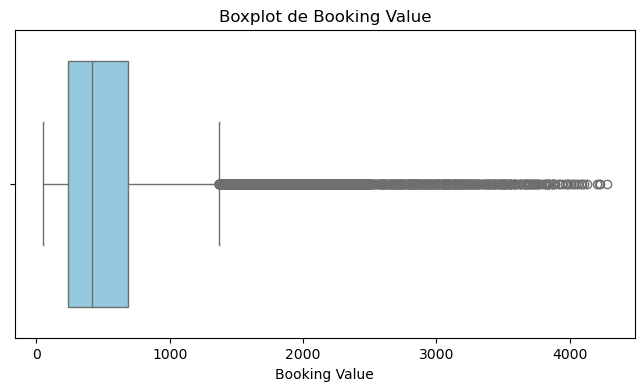

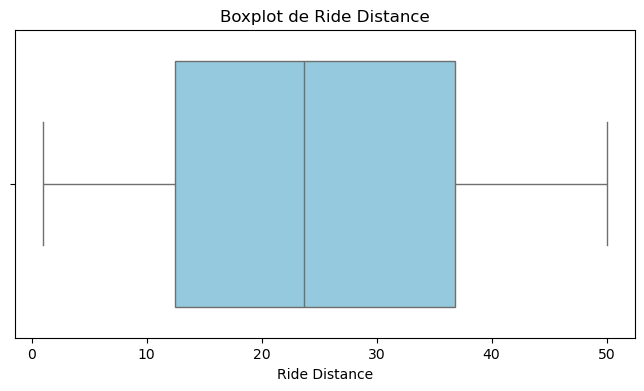

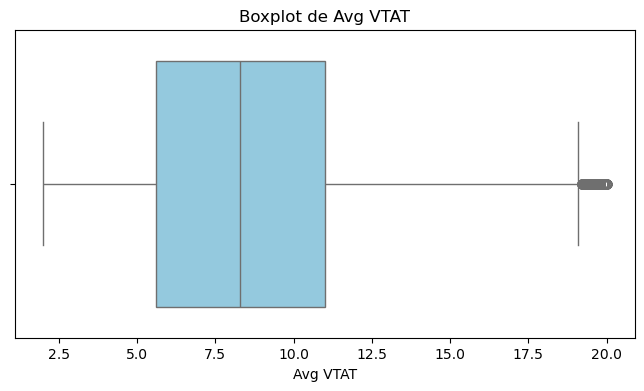

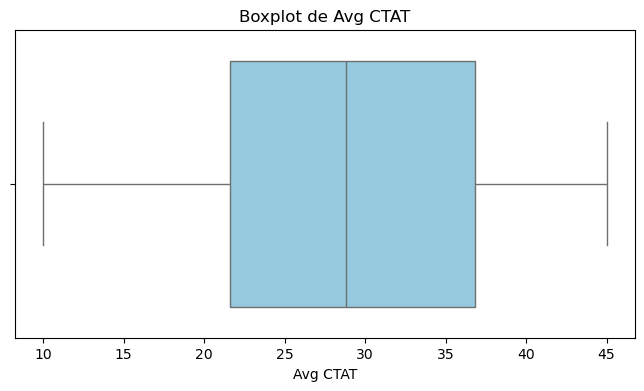

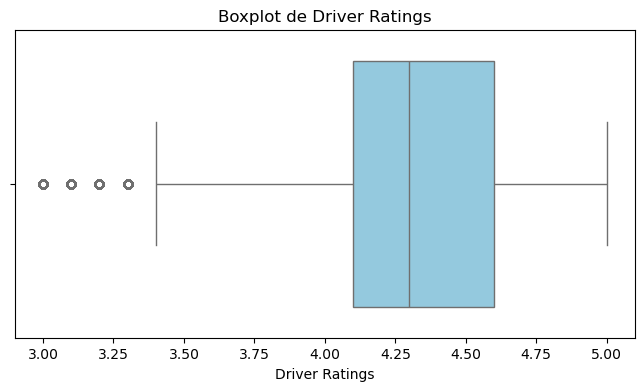

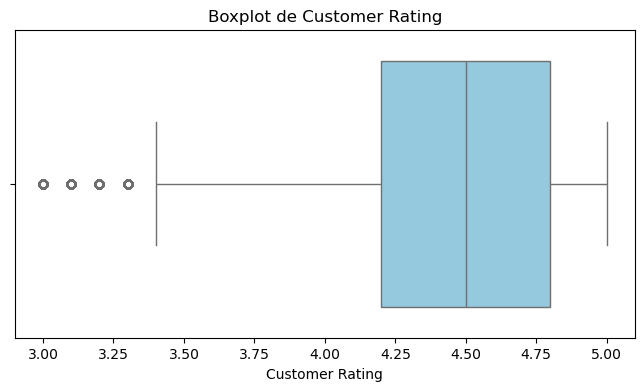

In [494]:
import seaborn as sns
import matplotlib.pyplot as plt

# Colonnes numériques à analyser
numeric_columns = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT",
    "Driver Ratings",
    "Customer Rating"
]

# Créer un boxplot pour chaque colonne
for col in numeric_columns:
    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col], color="skyblue")

    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)

    plt.show()

In [495]:
# Détecter le nombre de valeurs aberrantes (Outliers) avec la méthode IQR

numeric_columns = [
    "Booking Value",
    "Ride Distance",
    "Avg VTAT",
    "Avg CTAT",
    "Driver Ratings",
    "Customer Rating"
]

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_limit) |
        (df[col] > upper_limit)
    ]

    print(f"{col}")
    print(f"Nombre d'outliers : {len(outliers)}")
    print("-" * 40)

Booking Value
Nombre d'outliers : 3435
----------------------------------------
Ride Distance
Nombre d'outliers : 0
----------------------------------------
Avg VTAT
Nombre d'outliers : 631
----------------------------------------
Avg CTAT
Nombre d'outliers : 0
----------------------------------------
Driver Ratings
Nombre d'outliers : 5203
----------------------------------------
Customer Rating
Nombre d'outliers : 3257
----------------------------------------


## fix outlires Booking values

In [496]:
# Afficher quelques valeurs aberrantes de Booking Value

Q1 = df["Booking Value"].quantile(0.25)
Q3 = df["Booking Value"].quantile(0.75)
IQR = Q3 - Q1

outliers_booking = df[
    (df["Booking Value"] < Q1 - 1.5*IQR) |
    (df["Booking Value"] > Q3 + 1.5*IQR)
]

outliers_booking[["Booking ID", "Vehicle Type", "Booking Value"]].head(10)

,Booking ID,Vehicle Type,Booking Value
29,CNR8779845,Auto,2847.0
50,CNR1572483,Go Mini,1581.0
80,CNR4487090,Premier Sedan,1390.0
91,CNR7449144,Auto,2169.0
212,CNR5269641,Go Mini,1543.0
223,CNR1254363,Auto,1444.0
402,CNR9159821,Go Sedan,1523.0
418,CNR8081487,Premier Sedan,1563.0
429,CNR1559285,Auto,1596.0
561,CNR7698052,Go Sedan,1727.0


In [497]:
outliers_booking[
    [
        "Booking ID",
        "Booking Status",
        "Vehicle Type",
        "Ride Distance",
        "Booking Value"
    ]
].head(20)

,Booking ID,Booking Status,Vehicle Type,Ride Distance,Booking Value
29,CNR8779845,Completed,Auto,39.21,2847.0
50,CNR1572483,Incomplete,Go Mini,1.82,1581.0
80,CNR4487090,Completed,Premier Sedan,21.79,1390.0
91,CNR7449144,Completed,Auto,44.25,2169.0
212,CNR5269641,Completed,Go Mini,49.71,1543.0
223,CNR1254363,Completed,Auto,15.43,1444.0
402,CNR9159821,Completed,Go Sedan,6.84,1523.0
418,CNR8081487,Completed,Premier Sedan,8.86,1563.0
429,CNR1559285,Completed,Auto,38.53,1596.0
561,CNR7698052,Completed,Go Sedan,46.07,1727.0


In [498]:
df["Payment Method"]

0                 NaN
1                 UPI
2          Debit Card
3                 UPI
4                 UPI
             ...     
149995    Uber Wallet
149996            UPI
149997           Cash
149998            UPI
149999    Credit Card
Name: Payment Method, Length: 150000, dtype: object

In [499]:
df["Price_per_km"] = df["Booking Value"] / df["Ride Distance"]

df.sort_values(
    by="Price_per_km",
    ascending=False
)[
    [
        "Booking ID",
        "Booking Status",
        "Vehicle Type",
        "Ride Distance",
        "Booking Value",
        "Price_per_km",
        "Payment Method"
    ]
].head(20)

,Booking ID,Booking Status,Vehicle Type,Ride Distance,Booking Value,Price_per_km,Payment Method
24759,CNR3705367,Incomplete,Premier Sedan,1.00,3148.0,3148.000000,Uber Wallet
51750,CNR8682875,Incomplete,Go Mini,1.41,3060.0,2170.212766,Cash
121945,CNR3303271,Completed,Premier Sedan,2.06,3434.0,1666.990291,UPI
100563,CNR9120177,Completed,Go Sedan,2.31,3834.0,1659.740260,Cash
127717,CNR1834127,Incomplete,Premier Sedan,1.29,2102.0,1629.457364,UPI
86947,CNR4939487,Completed,Bike,2.38,3767.0,1582.773109,Cash
38945,CNR7942625,Completed,Auto,2.35,3487.0,1483.829787,Uber Wallet
13504,CNR3283452,Incomplete,Go Sedan,2.69,3554.0,1321.189591,Cash
132831,CNR8210349,Incomplete,Uber XL,1.01,1325.0,1311.881188,Uber Wallet
78576,CNR2137752,Incomplete,Auto,2.69,3491.0,1297.769517,UPI


In [500]:
df.groupby("Booking Status")["Price_per_km"].describe()

,count,mean,std,min,25%,50%,75%,max
Booking Status,,,,,,,,
Cancelled by Customer,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancelled by Driver,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Completed,93000.0,33.856378,54.137711,1.008065,8.988193,17.703937,35.576148,1666.990291
Incomplete,9000.0,79.422704,120.291406,2.630195,22.327583,43.314236,84.732246,3148.000000
No Driver Found,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


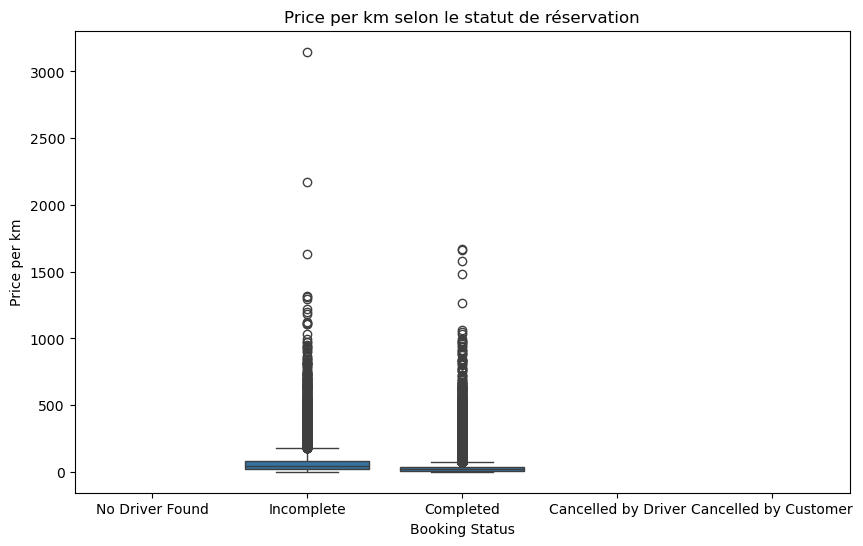

In [501]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Booking Status",
    y="Price_per_km"
)

plt.title("Price per km selon le statut de réservation")
plt.xlabel("Booking Status")
plt.ylabel("Price per km")

plt.show()

#J’ai calculé le prix par kilomètre (Price_per_km) afin d’identifier les observations inhabituelles. 
# Les statistiques montrent que les courses Incomplete présentent un prix moyen par kilomètre plus élevé que les courses Completed.
#  De plus, certaines valeurs maximales sont très importantes. Cependant, sans informations sur la politique tarifaire
#  (frais fixes, tarification dynamique ou estimation avant la course), il n’est pas possible d’affirmer qu’il s’agit d’erreurs.
#  J’ai donc choisi de conserver ces observations et de les signaler pour une analyse complémentaire.



In [502]:
completed = df[df["Booking Status"] == "Completed"]

completed.sort_values(
    by="Price_per_km",
    ascending=False
)[
    [
        "Booking ID",
        "Vehicle Type",
        "Ride Distance",
        "Booking Value",
        "Price_per_km"
    ]
].head(20)

# J’ai calculé le prix par kilomètre (Price_per_km) pour détecter les observations atypiques.
#  Certaines courses présentent un coût très élevé pour une distance très courte.
#  Cependant, le jeu de données ne fournit pas suffisamment d’informations sur la méthode de calcul du prix (tarification dynamique, frais fixes, 
# etc.). Je n’ai donc pas supprimé ces observations, car elles peuvent représenter des cas réels. 
# Je les ai simplement identifiées comme des valeurs atypiques qui méritent une analyse complémentaire.


,Booking ID,Vehicle Type,Ride Distance,Booking Value,Price_per_km
121945,CNR3303271,Premier Sedan,2.06,3434.0,1666.990291
100563,CNR9120177,Go Sedan,2.31,3834.0,1659.740260
86947,CNR4939487,Bike,2.38,3767.0,1582.773109
38945,CNR7942625,Auto,2.35,3487.0,1483.829787
90255,CNR9755722,Go Mini,2.29,2894.0,1263.755459
90426,CNR1410859,Premier Sedan,3.59,3825.0,1065.459610
96004,CNR9956539,Premier Sedan,2.71,2849.0,1051.291513
132857,CNR5360354,Go Sedan,2.15,2227.0,1035.813953
4272,CNR3423880,Go Sedan,2.89,2877.0,995.501730
14837,CNR6159231,Go Mini,2.15,2112.0,982.325581


# fix outliers Driver & ccustomer Ratings 

In [503]:
# Vérifier les valeurs hors intervalle 0-5

print("Driver Ratings incorrectes:")
print(df[(df["Driver Ratings"] < 0) | (df["Driver Ratings"] > 5)])

print("Customer Rating incorrectes:")
print(df[(df["Customer Rating"] < 0) | (df["Customer Rating"] > 5)])

Driver Ratings incorrectes:
Empty DataFrame
Columns: [Date, Time, Booking ID, Booking Status, Customer ID, Vehicle Type, Pickup Location, Drop Location, Avg VTAT, Avg CTAT, Cancelled Rides by Customer, Reason for cancelling by Customer, Cancelled Rides by Driver, Driver Cancellation Reason, Incomplete Rides, Incomplete Rides Reason, Booking Value, Ride Distance, Driver Ratings, Customer Rating, Payment Method, Price_per_km]
Index: []

[0 rows x 22 columns]
Customer Rating incorrectes:
Empty DataFrame
Columns: [Date, Time, Booking ID, Booking Status, Customer ID, Vehicle Type, Pickup Location, Drop Location, Avg VTAT, Avg CTAT, Cancelled Rides by Customer, Reason for cancelling by Customer, Cancelled Rides by Driver, Driver Cancellation Reason, Incomplete Rides, Incomplete Rides Reason, Booking Value, Ride Distance, Driver Ratings, Customer Rating, Payment Method, Price_per_km]
Index: []

[0 rows x 22 columns]


In [504]:
# Calculer les outliers de Driver Ratings avec la méthode IQR

Q1 = df["Driver Ratings"].quantile(0.25)
Q3 = df["Driver Ratings"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Extraire uniquement les valeurs considérées comme outliers
driver_rating_outliers = df[
    (df["Driver Ratings"] < lower_limit) |
    (df["Driver Ratings"] > upper_limit)
]

# Afficher les valeurs uniques des outliers
print(driver_rating_outliers["Driver Ratings"].value_counts().sort_index())

Driver Ratings
3.0     745
3.1    1459
3.2    1538
3.3    1461
Name: count, dtype: int64


In [505]:
driver_rating_outliers[
    ["Booking ID", "Vehicle Type", "Driver Ratings"]
].head(20)

,Booking ID,Vehicle Type,Driver Ratings
29,CNR8779845,Auto,3.1
60,CNR5316307,Premier Sedan,3.3
67,CNR9252424,eBike,3.2
92,CNR1970319,eBike,3.2
102,CNR8036415,eBike,3.2
108,CNR6596872,Auto,3.3
145,CNR1361929,Go Mini,3.1
202,CNR7484371,Go Sedan,3.2
263,CNR3460247,Bike,3.2
334,CNR4090725,Bike,3.2


# Reason for cancelling by Customer

In [506]:
customer_cancel = (
    df[df["Reason for cancelling by Customer"] != "Not Applicable"]
    ["Reason for cancelling by Customer"]
    .value_counts()
)

customer_cancel_percent = (
    customer_cancel / customer_cancel.sum() * 100
).round(2)

summary = pd.DataFrame({
    "Nombre": customer_cancel,
    "Pourcentage (%)": customer_cancel_percent
})

print(summary)

# Les résultats montrent que les quatre premières raisons ont des fréquences très proches, 
# ce qui indique qu'aucune raison ne domine fortement les annulations des clients. En revanche, 
# le problème lié à la climatisation est moins fréquen

                                              Nombre  Pourcentage (%)
Reason for cancelling by Customer                                    
Wrong Address                                   2362            22.50
Change of plans                                 2353            22.41
Driver is not moving towards pickup location    2335            22.24
Driver asked to cancel                          2295            21.86
AC is not working                               1155            11.00


# Driver Cancellation Reason

Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64
                                     Nombre  Pourcentage (%)
Driver Cancellation Reason                                  
Customer related issue                 6837            25.32
The customer was coughing/sick         6751            25.00
Personal & Car related issues          6726            24.91
More than permitted people in there    6686            24.76


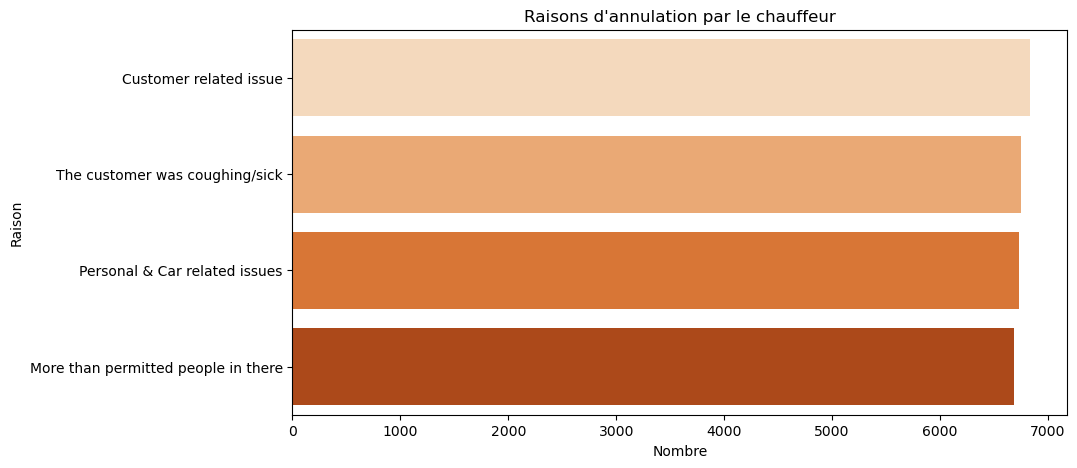

In [507]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclure les valeurs "Not Applicable"
driver_cancel = (
    df[df["Driver Cancellation Reason"] != "Not Applicable"]
    ["Driver Cancellation Reason"]
    .value_counts()
)

print(driver_cancel)

plt.figure(figsize=(10,5))

sns.barplot(
    x=driver_cancel.values,
    y=driver_cancel.index,
    hue=driver_cancel.index,
    palette="Oranges",
    legend=False
)

plt.title("Raisons d'annulation par le chauffeur")
plt.xlabel("Nombre")
plt.ylabel("Raison")

driver_cancel_percent = (
    driver_cancel / driver_cancel.sum() * 100
).round(2)

summary = pd.DataFrame({
    "Nombre": driver_cancel,
    "Pourcentage (%)": driver_cancel_percent
})

print(summary)

plt.show()

# Les fréquences sont très proches, ce qui montre que les annulations des
# chauffeurs sont réparties entre plusieurs causes et qu'aucune raison ne
#  domine largement les autres

# Incomplete Rides Reason"

Incomplete Rides Reason
Customer Demand      3040
Vehicle Breakdown    3012
Other Issue          2948
Name: count, dtype: int64


C:\Users\Moubarak\AppData\Local\Temp\ipykernel_8116\235615216.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


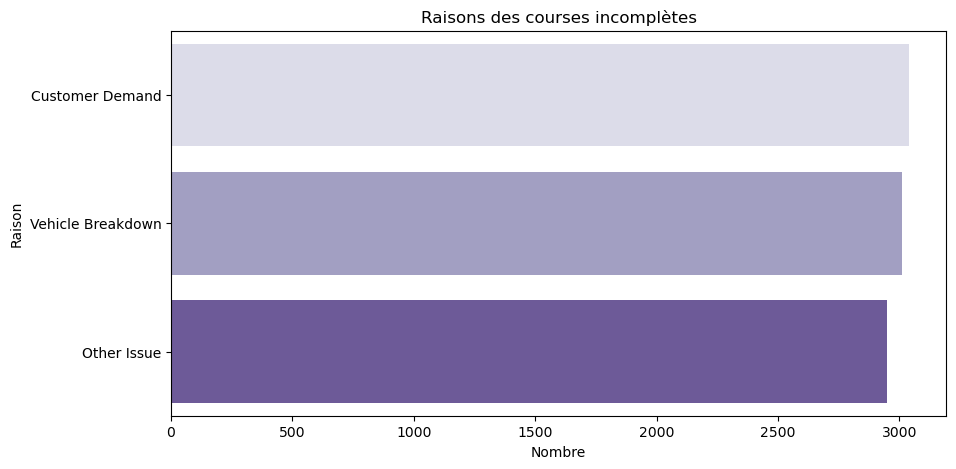

In [508]:
incomplete = (
    df[df["Incomplete Rides Reason"]!= "Not Applicable"]
    ['Incomplete Rides Reason']
    .value_counts()
)


print(incomplete)

plt.figure(figsize=(10,5))

sns.barplot(
    x=incomplete.values,
    y=incomplete.index,
    palette="Purples"
)

plt.title("Raisons des courses incomplètes")
plt.xlabel("Nombre")
plt.ylabel("Raison")

plt.show()

#L’analyse des courses incomplètes montre trois principales causes :
# Customer Demand : 3040 cas
# Vehicle Breakdown : 3012 cas
# Other Issue : 2948 cas

# Les fréquences sont très proches, ce qui indique qu’aucune cause ne domine fortement les courses incomplètes.
# Les interruptions sont liées à la fois aux demandes des clients, aux problèmes techniques des véhicules et à d’autres facteurs opération

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64


C:\Users\Moubarak\AppData\Local\Temp\ipykernel_8116\1246718238.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


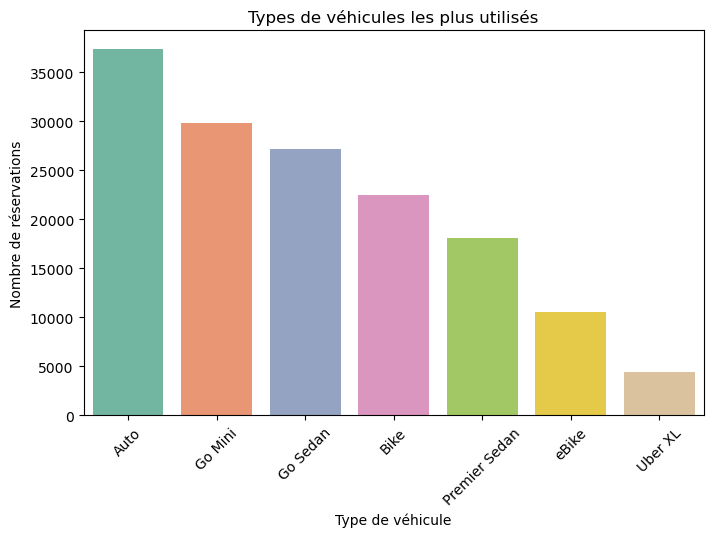

In [509]:
vehicle = df["Vehicle Type"].value_counts()

print(vehicle)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Vehicle Type",
    order=vehicle.index,
    palette="Set2"
)

plt.title("Types de véhicules les plus utilisés")
plt.xlabel("Type de véhicule")
plt.ylabel("Nombre de réservations")

plt.xticks(rotation=45)

plt.show()

# L’analyse des types de véhicules montre que Auto est le type de véhicule le plus utilisé avec 37 419 réservations, 
# suivi par Go Mini et Go Sedan. À l’inverse, Uber XL représente le type le moins demandé avec 4 449 réservations. 
# Cela indique une préférence des clients pour les véhicules standards et économiques.

# Type de voiture influe-t-il sur le motif d'annulation ?

In [510]:
vehicle_status_percent = (
    pd.crosstab(
        df["Vehicle Type"],
        df["Booking Status"],
        normalize="index"
    ) * 100
)

print(vehicle_status_percent.round(2))

# L’analyse de la relation entre le type de véhicule et le statut de réservation montre que 
# les performances sont très similaires entre les différentes catégories de véhicules.

# Le taux de courses terminées est compris entre 61 % et 63 % pour tous les types de véhicules.
# Les différences concernant les annulations clients, les annulations chauffeurs et les courses incomplètes restent faibles.

# Ainsi, aucune relation significative n’a été identifiée entre le type de véhicule et le résultat de la réservation.
# Le type de véhicule ne semble pas être un facteur majeur influençant les annulations ou les courses incomplètes.

Booking Status  Cancelled by Customer  Cancelled by Driver  Completed  \
Vehicle Type                                                            
Auto                             7.16                17.75      61.88   
Bike                             6.99                18.11      62.33   
Go Mini                          7.04                17.88      62.23   
Go Sedan                         6.75                18.54      61.44   
Premier Sedan                    6.99                17.94      62.13   
Uber XL                          7.35                17.13      62.55   
eBike                            6.85                18.06      62.05   

Booking Status  Incomplete  No Driver Found  
Vehicle Type                                 
Auto                  6.04             7.16  
Bike                  5.90             6.67  
Go Mini               6.09             6.76  
Go Sedan              6.05             7.22  
Premier Sedan         5.87             7.07  
Uber XL             

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


C:\Users\Moubarak\AppData\Local\Temp\ipykernel_8116\2165778432.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


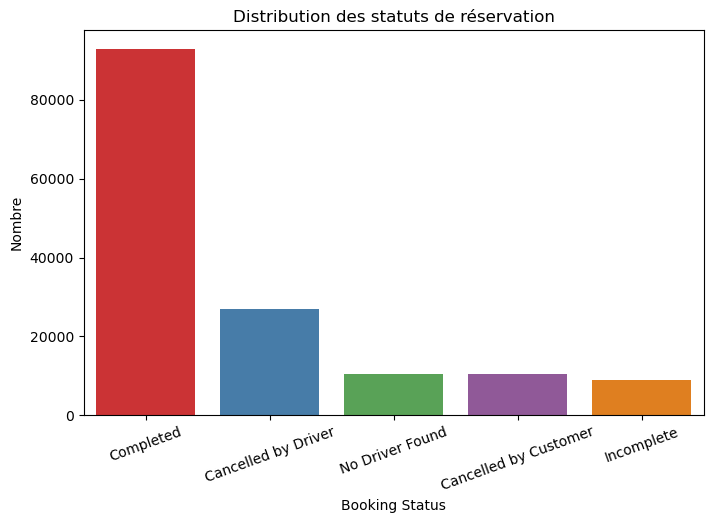

In [511]:
status = df["Booking Status"].value_counts()

print(status)

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Booking Status",
    order=status.index,
    palette="Set1"
)

plt.title("Distribution des statuts de réservation")
plt.xlabel("Booking Status")
plt.ylabel("Nombre")

plt.xticks(rotation=20)

plt.show()

In [512]:
booking_status_percent = (
    df["Booking Status"]
    .value_counts(normalize=True) * 100
)

print(booking_status_percent.round(2))

Booking Status
Completed                62.0
Cancelled by Driver      18.0
No Driver Found           7.0
Cancelled by Customer     7.0
Incomplete                6.0
Name: proportion, dtype: float64


## Taux d'échec des réservations selon l'heure

In [513]:
# Convertir Time en datetime puis extraire l'heure

df["Hour"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S"
).dt.hour

In [514]:
hour_status = pd.crosstab(
    df["Hour"],
    df["Booking Status"]
)

print(hour_status)

Booking Status  Cancelled by Customer  Cancelled by Driver  Completed  \
Hour                                                                    
0                                  92                  248        858   
1                                  94                  250        828   
2                                  75                  222        853   
3                                  92                  263        860   
4                                  98                  240        830   
5                                 204                  532       1715   
6                                 306                  699       2609   
7                                 376                 1006       3346   
8                                 493                 1221       4267   
9                                 559                 1492       5084   
10                                670                 1715       5983   
11                                557              

In [515]:
failed_status = [
    "Cancelled by Driver",
    "Cancelled by Customer",
    "Incomplete",
    "No Driver Found"
]


hour_failure = (
    df["Booking Status"]
    .isin(failed_status)
    .groupby(df["Hour"])
    .mean()
    * 100
)


print(hour_failure.round(2))


Hour
0     37.51
1     39.12
2     36.30
3     37.82
4     37.17
5     38.44
6     37.28
7     38.61
8     37.81
9     38.26
10    37.53
11    37.38
12    38.08
13    38.28
14    38.70
15    38.34
16    38.03
17    37.88
18    38.56
19    38.46
20    37.64
21    36.95
22    38.41
23    37.65
Name: Booking Status, dtype: float64


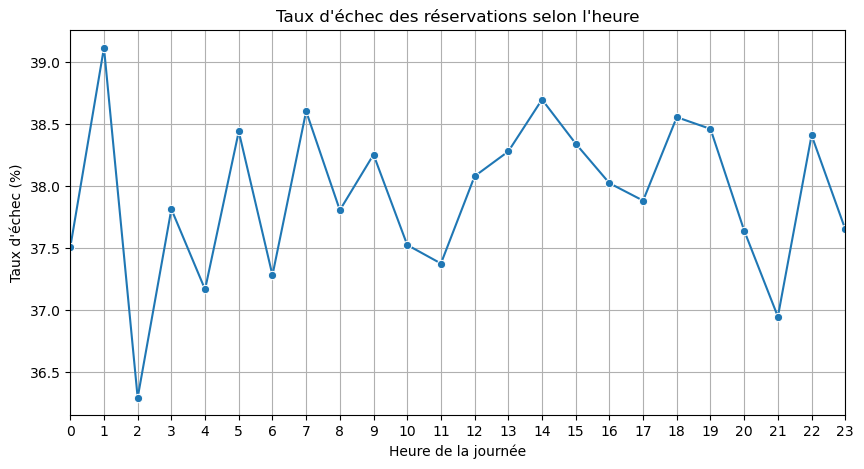

In [516]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=hour_failure.index,
    y=hour_failure.values,
    marker="o"
)

plt.title("Taux d'échec des réservations selon l'heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Taux d'échec (%)")

# Afficher toutes les heures de 0 à 23
plt.xticks(range(0,24))

plt.xlim(0,23)

plt.grid()

plt.show()

# L''heure de réservation ne semble pas être un facteur majeur influençant l'échec des courses. 
# Les annulations et les échecs sont répartis de manière relativement uniforme pendant la journée.

# Taux d'échec des réservations selon l'heure

In [528]:
# Convertir Date en datetime
df["Date"] = pd.to_datetime(df["Date"], format="%Y/%m/%d")

# Vérifier le type
print(df["Date"].dtype)

# Extraire le jour de la semaine
df["Day"] = df["Date"].dt.day_name()

# Afficher quelques lignes
print(df[["Date", "Day"]].head())

datetime64[ns]
        Date       Day
0 2024-03-23  Saturday
1 2024-11-29    Friday
2 2024-08-23    Friday
3 2024-10-21    Monday
4 2024-09-16    Monday


In [529]:
failed_status = [
    "Cancelled by Driver",
    "Cancelled by Customer",
    "Incomplete",
    "No Driver Found"
]

days_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

df["Day"] = pd.Categorical(
    df["Day"],
    categories=days_order,
    ordered=True
)

day_failure = (
    df["Booking Status"]
      .isin(failed_status)
      .groupby(df["Day"])
      .mean() * 100
)

print(day_failure.round(2))

Day
Monday       38.47
Tuesday      38.43
Wednesday    37.91
Thursday     37.75
Friday       38.06
Saturday     37.60
Sunday       37.78
Name: Booking Status, dtype: float64


C:\Users\Moubarak\AppData\Local\Temp\ipykernel_8116\1495863016.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(df["Day"])


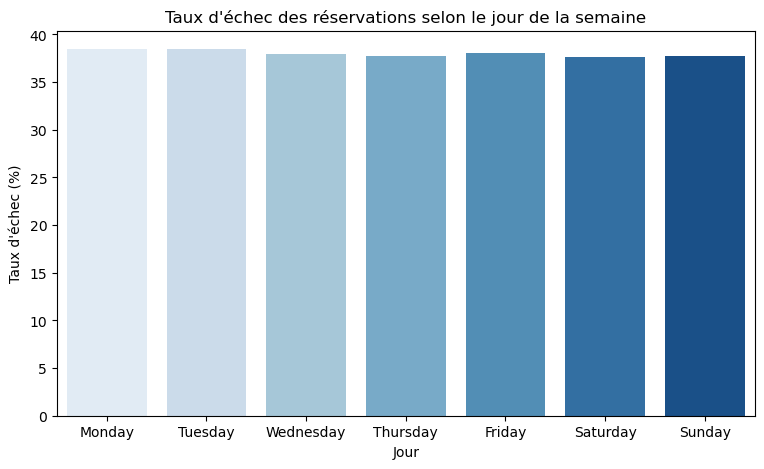

In [530]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9,5))

sns.barplot(
    x=day_failure.index,
    y=day_failure.values,
    hue=day_failure.index,
    palette="Blues",
    legend=False
)

plt.title("Taux d'échec des réservations selon le jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Taux d'échec (%)")

plt.show()

# les mois

In [531]:
# Extraire le mois
df["Month"] = df["Date"].dt.month_name()

# Ordre des mois
months_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

df["Month"] = pd.Categorical(
    df["Month"],
    categories=months_order,
    ordered=True
)

In [532]:
failed_status = [
    "Cancelled by Driver",
    "Cancelled by Customer",
    "Incomplete",
    "No Driver Found"
]

month_failure = (
    df["Booking Status"]
      .isin(failed_status)
      .groupby(df["Month"], observed=False)
      .mean()
      * 100
)

print(month_failure.round(2))

Month
January      38.18
February     38.22
March        37.46
April        37.44
May          38.14
June         37.64
July         38.54
August       38.43
September    38.42
October      37.51
November     38.20
December     37.79
Name: Booking Status, dtype: float64


In [534]:
bookings_per_month = df["Month"].value_counts().sort_index()

print(bookings_per_month)

Month
January      12861
February     11927
March        12719
April        12199
May          12778
June         12440
July         12897
August       12636
September    12248
October      12651
November     12394
December     12250
Name: count, dtype: int64


In [535]:
print(month_failure.round(2))

Month
January      38.18
February     38.22
March        37.46
April        37.44
May          38.14
June         37.64
July         38.54
August       38.43
September    38.42
October      37.51
November     38.20
December     37.79
Name: Booking Status, dtype: float64


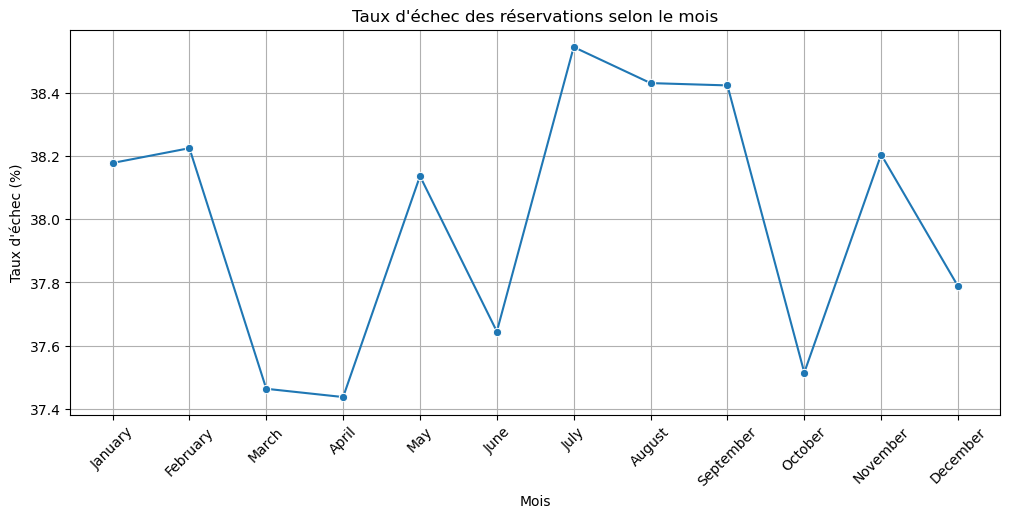

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

sns.lineplot(
    x=month_failure.index,
    y=month_failure.values,
    marker="o"
)

plt.title("Taux d'échec des réservations selon le mois")
plt.xlabel("Mois")
plt.ylabel("Taux d'échec (%)")

plt.grid(True)
plt.xticks(rotation=45)

plt.show()

# L'analyse du taux d'échec selon le mois montre des variations très limitées.
#  Le taux d'échec varie entre 37,44 % et 38,54 %, soit un écart d'environ 1,1 point de pourcentage. 
# Cette faible différence indique que le mois n'a pas d'influence significative sur la réussite des réservations.
# Les échecs des réservations semblent davantage liés à des facteurs opérationnels,
# tels que les annulations des chauffeurs, l'indisponibilité des véhicules ou les conditions de prise en charge,
# plutôt qu'à une période particulière de l'année.

#  Certaines zones génèrent-elles plus d'échecs ?

In [ ]:
pickup_status = pd.crosstab(
    df["Pickup Location"],
    df["Booking Status"]
)

print(pickup_status.head(10))

Booking Status    Cancelled by Customer  Cancelled by Driver  Completed  \
Pickup Location                                                           
AIIMS                                60                  176        562   
Adarsh Nagar                         62                  141        534   
Akshardham                           78                  170        471   
Ambience Mall                        58                  151        552   
Anand Vihar                          57                  142        553   
Anand Vihar ISBT                     69                  140        511   
Ardee City                           64                  144        545   
Arjangarh                            74                  135        486   
Ashok Park Main                      58                  151        568   
Ashok Vihar                          50                  143        492   

Booking Status    Incomplete  No Driver Found  
Pickup Location                                
AII

In [ ]:
location_failure = (
    df["Booking Status"]
    .isin(failed_status)
    .groupby(df["Pickup Location"])
    .mean()
    * 100
)


location_failure = (
    location_failure
    .sort_values(ascending=False)
)


print(location_failure.head(10))

Pickup Location
Vinobapuri              45.321993
Akshardham              43.861740
Chhatarpur              41.857660
Badshahpur              41.705069
Pragati Maidan          41.521739
Netaji Subhash Place    41.325301
Vatika Chowk            41.296519
Faridabad Sector 15     41.275572
Indirapuram             41.100703
IFFCO Chowk             40.843373
Name: Booking Status, dtype: float64


In [ ]:
top10 = location_failure.head(5).index

for zone in top5:
    print(f"\n===== {zone} =====")
    print(df[df["Pickup Location"] == zone]["Booking Status"].value_counts())


===== Vinobapuri =====
Booking Status
Completed                450
Cancelled by Driver      176
No Driver Found           76
Cancelled by Customer     68
Incomplete                53
Name: count, dtype: int64

===== Akshardham =====
Booking Status
Completed                471
Cancelled by Driver      170
Cancelled by Customer     78
Incomplete                61
No Driver Found           59
Name: count, dtype: int64

===== Chhatarpur =====
Booking Status
Completed                482
Cancelled by Driver      173
No Driver Found           63
Incomplete                56
Cancelled by Customer     55
Name: count, dtype: int64

===== Badshahpur =====
Booking Status
Completed                506
Cancelled by Driver      165
Cancelled by Customer     70
No Driver Found           70
Incomplete                57
Name: count, dtype: int64

===== Pragati Maidan =====
Booking Status
Completed                538
Cancelled by Driver      179
No Driver Found           70
Cancelled by Customer     69
I

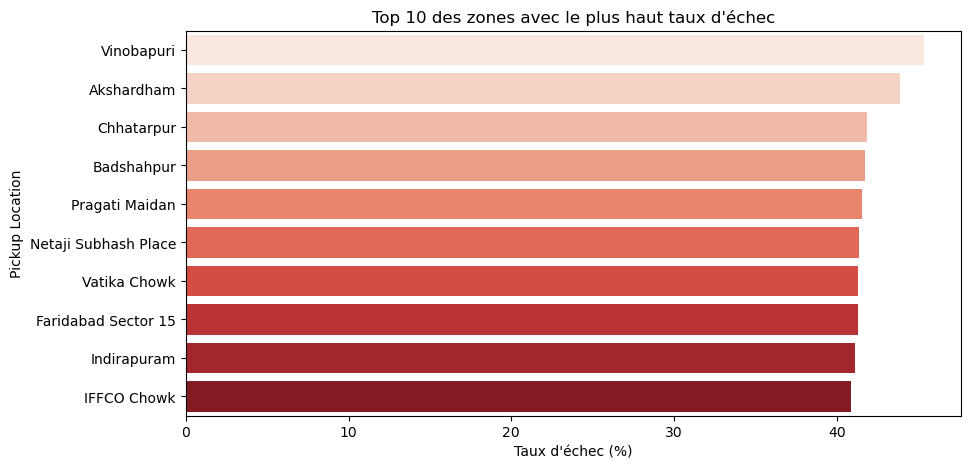

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=location_failure.head(10).values,
    y=location_failure.head(10).index,
    hue=location_failure.head(10).index,
    palette="Reds",
    legend=False
)

plt.title("Top 10 des zones avec le plus haut taux d'échec")
plt.xlabel("Taux d'échec (%)")
plt.ylabel("Pickup Location")

plt.show()

<Figure size 1200x700 with 0 Axes>

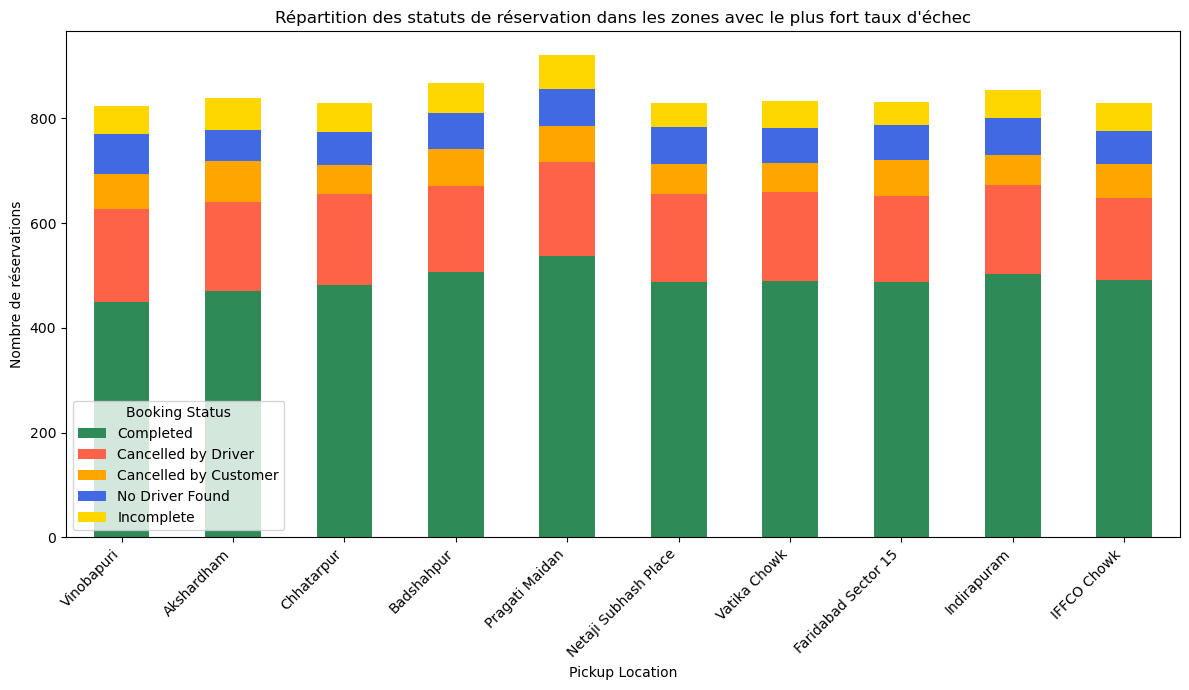

In [ ]:
import matplotlib.pyplot as plt

# Les 10 zones avec le plus fort taux d'échec
top10 = location_failure.head(10).index

# Tableau des statuts pour ces zones
top10_status = pd.crosstab(
    df["Pickup Location"],
    df["Booking Status"]
).loc[top10]

# Ordre des statuts
order = [
    "Completed",
    "Cancelled by Driver",
    "Cancelled by Customer",
    "No Driver Found",
    "Incomplete"
]

top10_status = top10_status[order]

# Couleurs
colors = [
    "seagreen",
    "tomato",
    "orange",
    "royalblue",
    "gold"
]

# Graphique
plt.figure(figsize=(12,7))

top10_status.plot(
    kind="bar",
    stacked=True,
    color=colors,
    figsize=(12,7)
)

plt.title("Répartition des statuts de réservation dans les zones avec le plus fort taux d'échec")
plt.xlabel("Pickup Location")
plt.ylabel("Nombre de réservations")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Booking Status")

plt.tight_layout()
plt.show()

# Ce graphique présente la répartition des différents statuts de réservation dans les dix zones ayant le taux d'échec le plus élevé.
#  On observe que les courses terminées (Completed) restent majoritaires, mais parmi les réservations non abouties,
#  les annulations par les chauffeurs constituent systématiquement la catégorie la plus importante.
#  Cela indique que les difficultés rencontrées dans ces zones sont principalement liées 
# aux annulations des chauffeurs plutôt qu'aux autres types d'échec.


